## Loading and Exploring Data

In [43]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [44]:
df = pd.read_csv(r"C:\Users\divya\Downloads\WA_Fn-UseC_-Telco-Customer-Churn.csv")
df.head(5)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [45]:
df.shape

(7043, 21)

In [46]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [47]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [48]:
df.dtypes

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

In [49]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

## Data Cleaning

In [50]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'].fillna(0, inplace=True)

C:\Users\divya\AppData\Local\Temp\ipykernel_9008\3380121502.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['TotalCharges'].fillna(0, inplace=True)


In [51]:
df.duplicated().sum()

np.int64(0)

In [52]:
df['Churn_flag'] = df['Churn'].map({'Yes':1,'No':0})
df['Churn_flag']

0       0
1       0
2       1
3       0
4       1
       ..
7038    0
7039    0
7040    0
7041    1
7042    0
Name: Churn_flag, Length: 7043, dtype: int64

## Exploratory Data Analysis (EDA)

In [53]:
# overall churn rate 
df['Churn_flag'].mean()*100

np.float64(26.536987079369588)

In [54]:
# churn rate by contract type
df.groupby('Contract')['Churn_flag'].mean().sort_values(ascending=False)

Contract
Month-to-month    0.427097
One year          0.112695
Two year          0.028319
Name: Churn_flag, dtype: float64

In [55]:
# Churn rate by tenure
df['tenure_group'] = pd.cut(df['tenure'],bins=[0,6,12,24,48,72],labels=['0-6','6-12','12-24','24-48','48-72'])
df.groupby('tenure_group')['Churn_flag'].mean().sort_values()

C:\Users\divya\AppData\Local\Temp\ipykernel_9008\150820379.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('tenure_group')['Churn_flag'].mean().sort_values()


tenure_group
48-72    0.095132
24-48    0.203890
12-24    0.287109
6-12     0.358865
0-6      0.533333
Name: Churn_flag, dtype: float64

In [56]:
# Churn rate by TechSupport
df.groupby('TechSupport')['Churn_flag'].mean().sort_values()

TechSupport
No internet service    0.074050
Yes                    0.151663
No                     0.416355
Name: Churn_flag, dtype: float64

In [57]:
# Churn rate by OnlineSecurity
df.groupby('OnlineSecurity')['Churn_flag'].mean().sort_values()

OnlineSecurity
No internet service    0.074050
Yes                    0.146112
No                     0.417667
Name: Churn_flag, dtype: float64

In [58]:
# Churn rate by PaymentMethod
df.groupby('PaymentMethod')['Churn_flag'].mean().sort_values()

PaymentMethod
Credit card (automatic)      0.152431
Bank transfer (automatic)    0.167098
Mailed check                 0.191067
Electronic check             0.452854
Name: Churn_flag, dtype: float64

In [59]:
# Churn rate by InternetService
df.groupby('InternetService')['Churn_flag'].mean().sort_values()

InternetService
No             0.074050
DSL            0.189591
Fiber optic    0.418928
Name: Churn_flag, dtype: float64

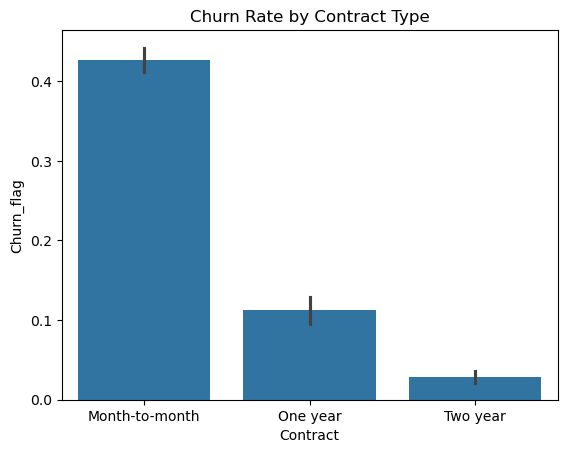

In [60]:
sns.barplot(x='Contract', y='Churn_flag', data=df)
plt.title('Churn Rate by Contract Type')
plt.show()

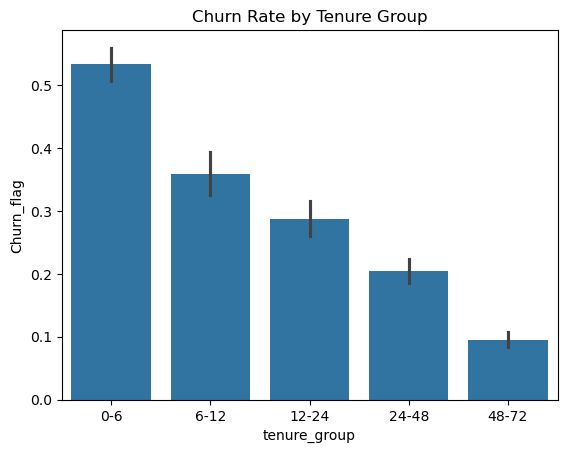

In [61]:
sns.barplot(x='tenure_group', y='Churn_flag', data=df)
plt.title('Churn Rate by Tenure Group')
plt.show()

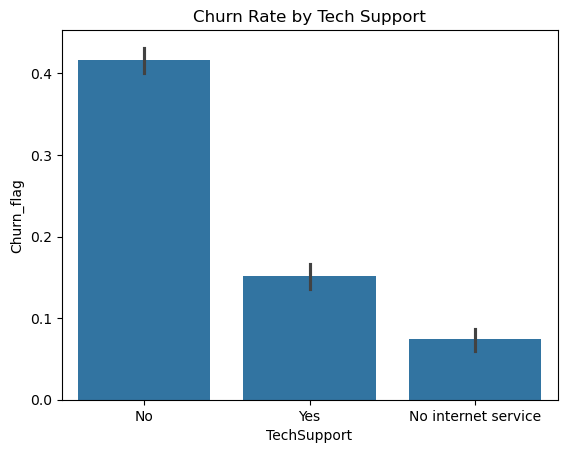

In [62]:
sns.barplot(x='TechSupport', y='Churn_flag', data=df)
plt.title('Churn Rate by Tech Support')
plt.show()

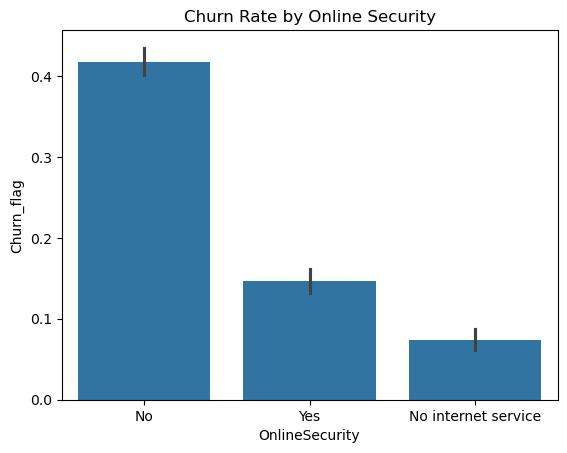

In [63]:
sns.barplot(x='OnlineSecurity', y='Churn_flag', data=df)
plt.title('Churn Rate by Online Security')
plt.show()

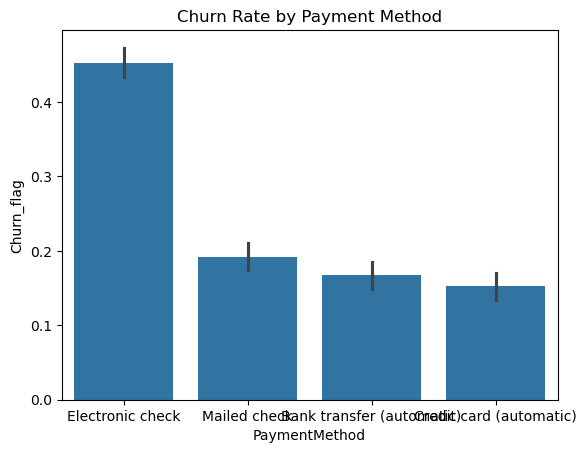

In [64]:
sns.barplot(x='PaymentMethod', y='Churn_flag', data=df)
plt.title('Churn Rate by Payment Method')
plt.show()

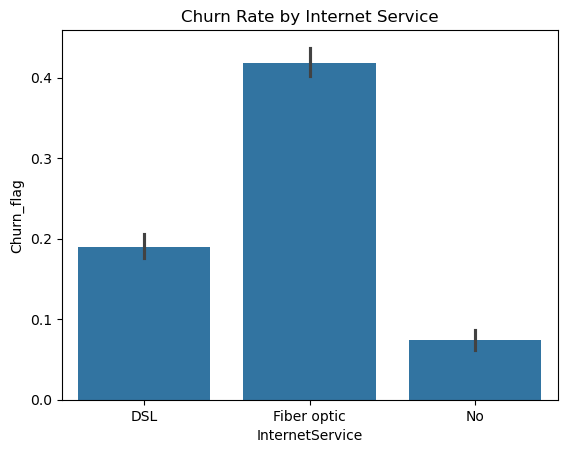

In [65]:
sns.barplot(x='InternetService', y='Churn_flag', data=df)
plt.title('Churn Rate by Internet Service')
plt.show()

## Key Insights from Exploratory Analysis

### 1. Contract type is the strongest churn driver
Month-to-month customers churn at **42.7%**, compared to **11.3%** for 
one-year contracts and just **2.8%** for two-year contracts — a 15x gap 
between the riskiest and safest contract type. This is the single biggest 
lever available: converting month-to-month customers to annual contracts, 
even with a discount incentive, would likely be far cheaper than losing 
them entirely.

### 2. Churn risk is heavily front-loaded in early tenure
Customers in their first 6 months churn at **53.3%** — over half leave 
before even completing their first year. Churn drops steadily with tenure, 
falling to **9.5%** for customers past 48 months. This suggests onboarding 
and early engagement (first 90-180 days) is the highest-risk window and 
where retention effort should be concentrated first.

### 3. Missing support/security add-ons roughly triples churn risk
Customers without Tech Support churn at **41.6%** vs **15.2%** for those 
who have it — nearly a 3x difference. The exact same pattern holds for 
Online Security (41.8% vs 14.6%). These aren't just add-on revenue — they 
appear to meaningfully increase customer stickiness, likely because they 
raise the switching cost or improve the customer's experience/trust.

### 4. Electronic check payers and Fiber optic users are high-risk segments
Electronic check payers churn at **45.3%** — nearly 3x higher than 
automatic payment methods (Credit card: 15.2%, Bank transfer: 16.7%). 
Since electronic check requires manual monthly payment, this likely 
reflects a mix of lower commitment and involuntary churn (failed manual 
payments). Similarly, Fiber optic customers churn at **41.9%** vs 19.0% 
for DSL — surprising, since fiber is the premium product, which may point 
to pricing dissatisfaction or service quality complaints specific to fiber.

## Building the Risk Score

In [66]:
def risk_score(row):
    score = 0
    
    if row['Contract'] == 'Month-to-month':
        score += 3
    
    if row['tenure'] < 6:
        score += 3
    
    if row['PaymentMethod'] == 'Electronic check':
        score += 2
    
    if row['TechSupport'] == 'No':
        score += 2
    
    if row['OnlineSecurity'] == 'No':
        score += 2
    
    if row['InternetService'] == 'Fiber optic':
        score += 1
    
    return score

df['RiskScore'] = df.apply(risk_score, axis=1)

In [67]:
df['RiskScore'].describe()
df['RiskScore'].value_counts().sort_index()

RiskScore
0     1450
1      232
2      473
3      686
4      239
5      561
6      536
7      414
8      764
9      162
10     835
11     180
12     148
13     363
Name: count, dtype: int64

In [68]:
df['RiskTier'] = pd.cut(df['RiskScore'], 
                          bins=[-1, 3, 7, 13], 
                          labels=['Low', 'Medium', 'High'])

In [69]:
df.groupby('RiskTier')['Churn_flag'].mean()

C:\Users\divya\AppData\Local\Temp\ipykernel_9008\2262330030.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('RiskTier')['Churn_flag'].mean()


RiskTier
Low       0.049630
Medium    0.212000
High      0.553426
Name: Churn_flag, dtype: float64

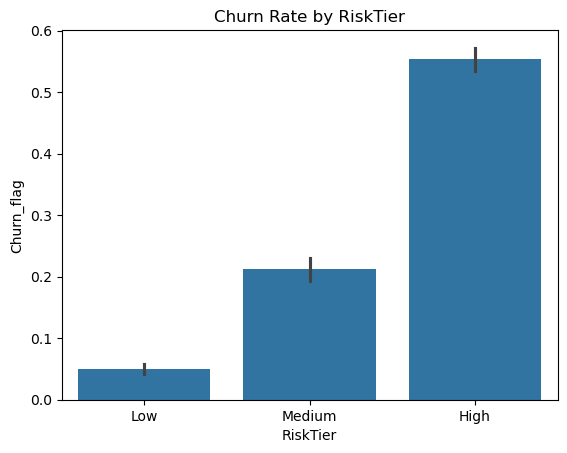

In [70]:
sns.barplot(x='RiskTier', y='Churn_flag', data=df)
plt.title('Churn Rate by RiskTier')
plt.show()

## Adding Value Customer

In [71]:
df['Customer_value'] = df['MonthlyCharges']*df['tenure']

In [72]:
df['ValueTier'] = np.where(df['Customer_value'] > df['Customer_value'].median(), 'High Value', 'Low Value')

## Building 2x2 Segmentation

In [73]:
segment_summary = df.groupby(['RiskTier','ValueTier']).agg(
    count=('customerID','count'),
    avg_value=('Customer_value','mean'),
    churn_rate=('Churn_flag','mean')
)
print(segment_summary)

                     count    avg_value  churn_rate
RiskTier ValueTier                                 
Low      High Value   1696  4475.789888    0.059552
         Low Value    1145   671.834105    0.034934
Medium   High Value    957  3999.943051    0.177638
         Low Value     793   507.410340    0.253468
High     High Value    868  3291.531855    0.449309
         Low Value    1584   383.541793    0.610480


C:\Users\divya\AppData\Local\Temp\ipykernel_9008\2656355219.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  segment_summary = df.groupby(['RiskTier','ValueTier']).agg(


In [74]:
priority = df[(df['RiskTier']=='High') & (df['ValueTier']=='High Value')]
print('Prior Customer:-',len(priority))
print('Total revenue:-',priority['Customer_value'].sum())

Prior Customer:- 868
Total revenue:- 2857049.65


## Business Recommendation: ROI on Retention Offer

The High Risk / High Value segment (868 customers, ~₹28.6L total value, 44.9% 
churn rate) represents the highest-priority group for retention spend. Without 
intervention, an estimated 390 of these customers will churn, putting ~₹12.8L 
in revenue at risk.

A targeted 10% retention discount offered to this segment would cost 
approximately ₹2.86L. Even a conservative 30% success rate in preventing churn 
(saving ~117 customers) would protect ~₹3.85L in revenue — a 1.35x return on 
the campaign cost. This makes the offer clearly worth pursuing, even under 
cautious assumptions.

## Retention Strategy by Segment

**High Risk / High Value (868 customers, 44.9% churn)**
Top priority. Proactively reach out with a personal touch — a retention call 
or account manager check-in, not just an automated email — paired with a 
targeted discount or free service upgrade (e.g., free Tech Support add-on, 
since we found that reduces churn ~3x). The ROI math above supports the spend 
here.

**High Risk / Low Value (1,584 customers, 61.0% churn)**
Largest and riskiest group, but lowest value — not worth expensive interventions. 
Use low-cost, automated retention tactics: an email nudge, a small self-service 
discount code, or a prompt to switch off Electronic Check to automatic payment 
(reduces involuntary churn from failed payments). Do not allocate phone/agent 
time here.

**Medium Risk / High Value (957 customers, 17.8% churn)**
Worth monitoring closely rather than acting immediately. A good candidate for 
an annual-contract upgrade incentive (since month-to-month is a major churn 
driver) — offer a modest discount for switching to a 1-year plan, locking in 
both lower churn risk and predictable revenue.

**Medium Risk / Low Value (793 customers, 25.3% churn)**
Low-touch, low-cost tactics only — automated check-in emails, self-service 
account tips. Not worth manual outreach given the value size, but cheap to 
include in a broader retention email campaign.

**Low Risk / High Value (1,696 customers, 6.0% churn)**
Protect, don't chase. These are your best customers — the risk here isn't 
churn, it's complacency. Focus on loyalty/rewards rather than discounts, e.g., 
early access to new features, small appreciation perks, to maintain satisfaction 
without unnecessary discount spend.

**Low Risk / Low Value (1,145 customers, 3.5% churn)**
Deprioritize entirely. No retention spend needed — churn risk is already low 
and value is low, so this segment isn't worth active management right now.